In [1]:
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import *
from plotting import *
from get_LrLx_data import *
from coordinate_conversions import *

# Coordinates

In [ ]:
#https://www.astronomerstelegram.org/?read=14591

In [2]:
icrs_to_galactic(ra_deg = 270.76162, dec_deg = -29.83046)

Galactic l: 1.147192806826462
Galactic b: -3.7275042329006047


# Get Data

In [3]:
source_df, obs_df, radio_df, xray_df = read_data("../DATA/MAXI J1803-298.txt")

MAXI J1803-298
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


In [4]:
obs_df

,name,xray_CI,xray_obs_ref,radio_obs_ref,extra_xray_text,extra_radio_text
0,MAXI J1803-298,90,[Espinasse et al. (in prep.) & ],[Espinasse et al. (in prep.) & ],NaN,NaN


In [5]:
radio_df.head()

,name,blockID,band,t_radio,dt_radio,Rphase,Rstate,Fr,Fr_unc,local_rms,alpha,alpha_unc,Fr_uplim_bool
0,MAXI J1803-298,1620163936,L,59338.91,NaN,rise,HS,4.068,0.204696,NaN,0.18,0.03,False
1,MAXI J1803-298,1620351977,L,59341.13,NaN,rise,HS,6.114,0.306354,NaN,0.21,0.01,False
2,MAXI J1803-298,1621113378,L,59349.94,NaN,peak/trough,IMS,20.657,1.033129,NaN,-0.45,0.01,False
3,MAXI J1803-298,1621641679,L,59356.05,NaN,unclear,IMS,2.125,0.108116,NaN,NaN,NaN,False
4,MAXI J1803-298,1622155550,L,59361.98,NaN,unclear,SS,1.863,0.095273,NaN,NaN,NaN,False


In [6]:
xray_df.head(25)

,name,obsID,t_xray,dt_xray,Xphase,Xstate,Fx,Fx_unc_l,Fx_unc_u,model,fit_stat,Fx_uplim_bool
0,MAXI J1803-298,1046414000,59336.76987,0.057664,rise,HS,2.260000e-09,2.263268e-10,2.263268e-10,tbabs*cflux*powerlaw,chi,False
1,MAXI J1803-298,1046414002,59342.56904,0.008446,rise,HS,6.222000e-09,6.242922e-10,6.241939e-10,tbabs*cflux(powerlaw+diskbb),chi,False
2,MAXI J1803-298,14314002,59345.30305,0.004393,rise,IMS,1.075000e-08,1.081854e-09,1.081854e-09,tbabs*cflux(powerlaw+diskbb),chi,False
3,MAXI J1803-298,14314003,59346.10241,0.014971,peak/trough,IMS,1.969000e-08,1.974857e-09,1.974857e-09,tbabs*cflux(powerlaw+diskbb),chi,False
4,MAXI J1803-298,14314006,59347.29967,0.007005,unclear,IMS,1.396000e-08,1.399385e-09,1.399385e-09,tbabs*cflux(powerlaw+diskbb),chi,False
5,MAXI J1803-298,14314007,59348.82038,0.137736,unclear,IMS,1.881000e-08,1.882925e-09,1.882925e-09,tbabs*cflux(powerlaw+diskbb),chi,False
6,MAXI J1803-298,1046414003,59349.95423,0.007520,unclear,IMS,1.505000e-08,1.508140e-09,1.508140e-09,tbabs*cflux(powerlaw+diskbb),chi,False
7,MAXI J1803-298,14314008,59350.54885,0.676652,unclear,IMS,1.476000e-08,1.477014e-09,1.477014e-09,tbabs*cflux*diskbb,chi,False
8,MAXI J1803-298,14314009,59351.33958,0.267501,unclear,IMS,1.274000e-08,1.274928e-09,1.274928e-09,tbabs*cflux*diskbb,chi,False
9,MAXI J1803-298,14314010,59352.73365,0.148765,unclear,IMS,1.311000e-08,1.311691e-09,1.311691e-09,tbabs*cflux*diskbb,chi,False


# Light Curves

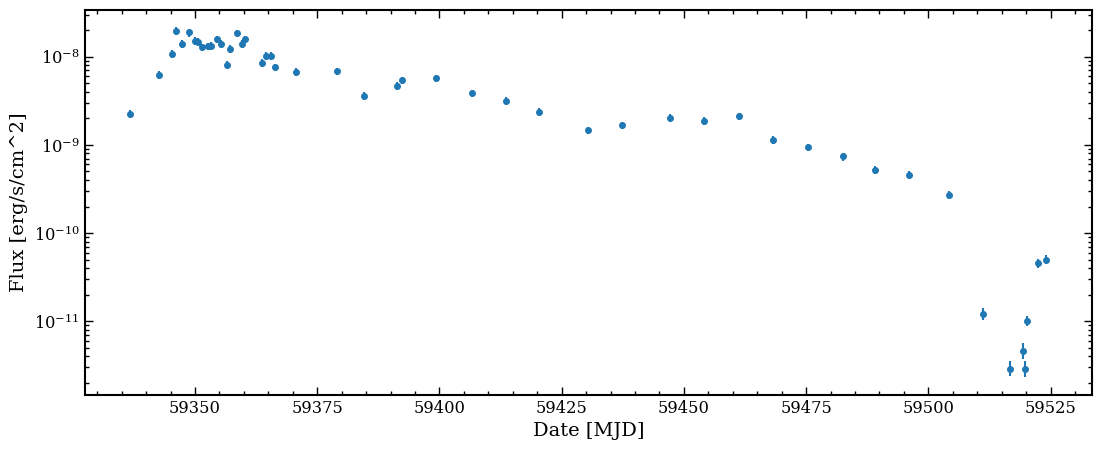

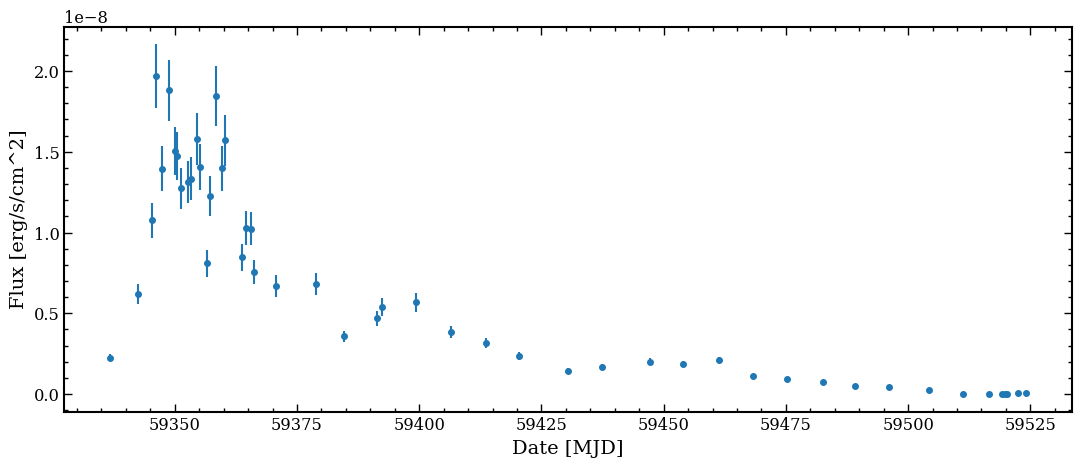

In [7]:
# WITH systematic errors
plot_xray_lightcurve(xray_df)

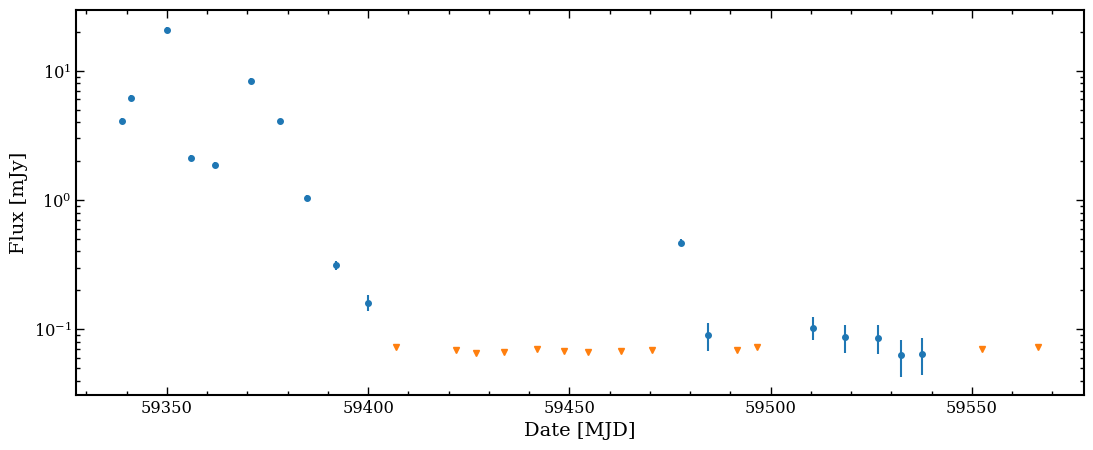

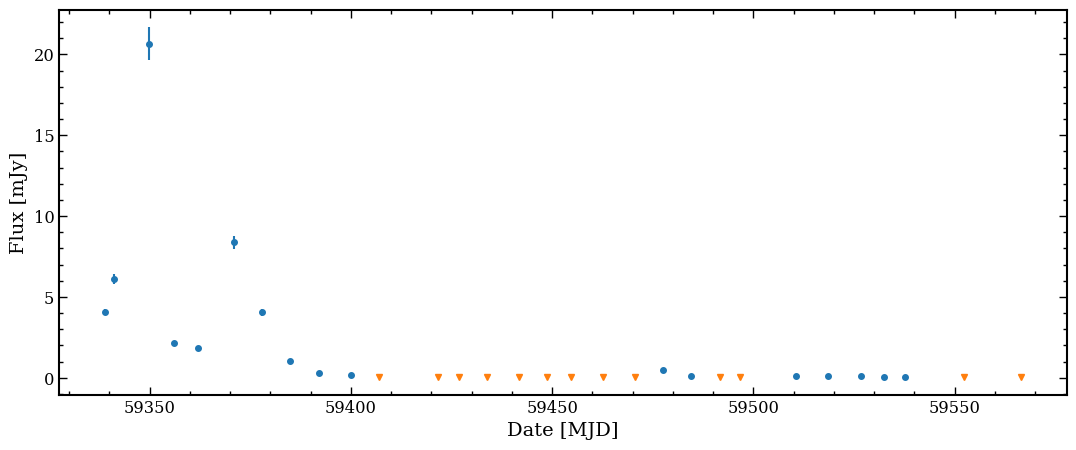

In [8]:
# WITH systematic error
plot_radio_lightcurve(radio_df)

# Pairing
There is one set of HS points at the start that are just longer than 1 day apart:
59341.13	59342.56

In [9]:
paired_data = make_paired_Lr_Lx_df(radio_df, xray_df, source_df)

t_radio             Fr [mJy]            Fr_unc [mJy]        #xray     t_diff                        Mean Fx [erg/cm^2/s]          Fx_unc_l[erg/cm^2/s]          Fx_unc_u[erg/cm^2/s]          Fr_uplim_bool  Fx_uplim_bool  state          
59349.940000000     20.65700            1.03313             2         [0.014 0.609]                 1.49020e-08                   1.05524e-09                   1.05524e-09                   False          False          IMS            
59356.050000000     2.12500             0.10812             2         [0.802 0.468]                 9.56122e-09                   7.02344e-10                   7.02344e-10                   False          False          IMS            
59370.930000000     8.37400             0.41923             1         [0.212]                       6.70100e-09                   6.73192e-10                   6.73250e-10                   False          False          SS             
59377.990000000     4.04100             0.20294         

In [10]:
paired_data[["t", "Lr", "Lx", "state"]]

,t,Lr,Lx,state
0,59349.94,2.025158e+30,1.141368e+38,IMS
1,59356.05,2.083294e+29,7.323103e+37,IMS
2,59370.93,8.209649e+29,5.132409e+37,SS
3,59377.99,3.961690e+29,5.217426e+37,SS
4,59384.94,1.013706e+29,2.738919e+37,SS
5,59392.07,3.078373e+28,3.825712e+37,SS
6,59399.94,1.578402e+28,4.350408e+37,SS
7,59407.05,7.156728e+27,2.941887e+37,SS
8,59454.66,6.568504e+27,1.427669e+37,SS
9,59496.64,7.156728e+27,3.507900e+36,SS


In [11]:
lr_all, lx_all, all_types = get_bahramian_data()

Only including detections from Bahramian et al. data.
Converting Bahramian Lr values from 5 GHz to 1.28 GHz, assuming flat spectral index.


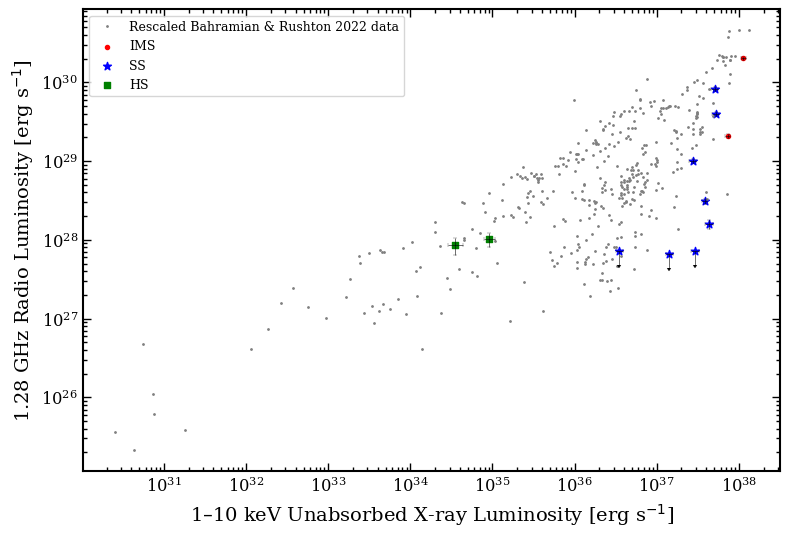

In [12]:
plot_Lr_Lx(paired_data, colourby="state", lx=lx_all, lr=lr_all)

# Interpolation

dt1, dt2:  3.0 10.0

Number of plotting points:  374
59338.91: time_to_nearest: 2.140130000007048 & time_to_furthest: 3.6590399999986403; y_predict_err: 0.04140008301722453
59341.13: time_to_nearest: 1.439040000004752 & time_to_furthest: 4.360130000000936; y_predict_err: 0.04381554728819914
59349.94: time_to_nearest: 0.014230000000679865 & time_to_furthest: 1.119620000004943; y_predict_err: 0.04629260490903153
59356.05: time_to_nearest: 0.467689999997674 & time_to_furthest: 0.8021399999997811; y_predict_err: 0.03414141678244853
59361.98: time_to_nearest: 1.6830800000025192 & time_to_furthest: 1.7783699999999953; y_predict_err: 0.036768770731137046
59370.93: time_to_nearest: 0.2117599999983213 & time_to_furthest: 8.026369999999588; y_predict_err: 0.04473286652422637
59377.99: time_to_nearest: 0.9663700000019162 & time_to_furthest: 7.271759999995993; y_predict_err: 0.04245798594371131
59384.94: time_to_nearest: 0.41982000000280095 & time_to_furthest: 6.365189999996801; y_predict_err: 0.0

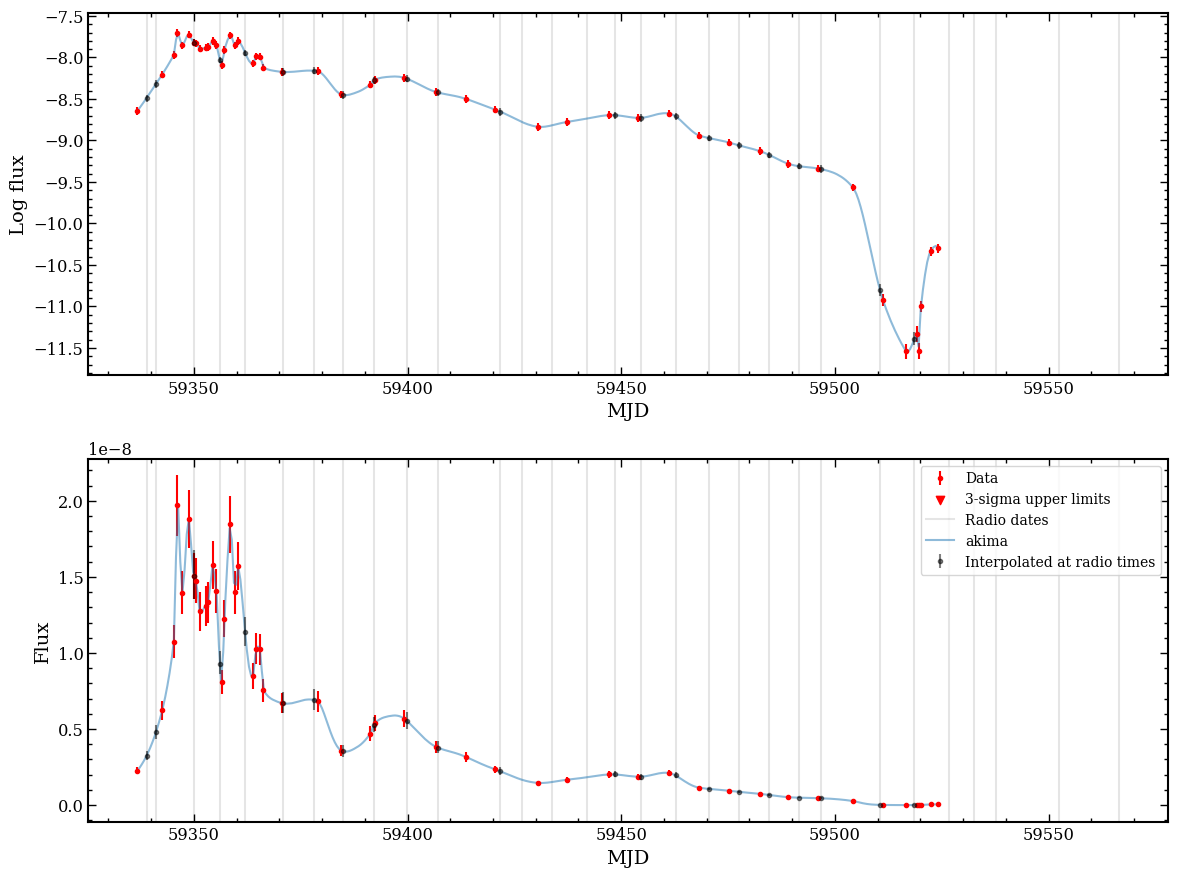

Number of used interpolated data points:  22
Converting to luminosity using d_kpc = 8.0


In [13]:
interpolated_data = make_interpolated_Lr_Lx_df(radio_df, xray_df, source_df, plotly=True)

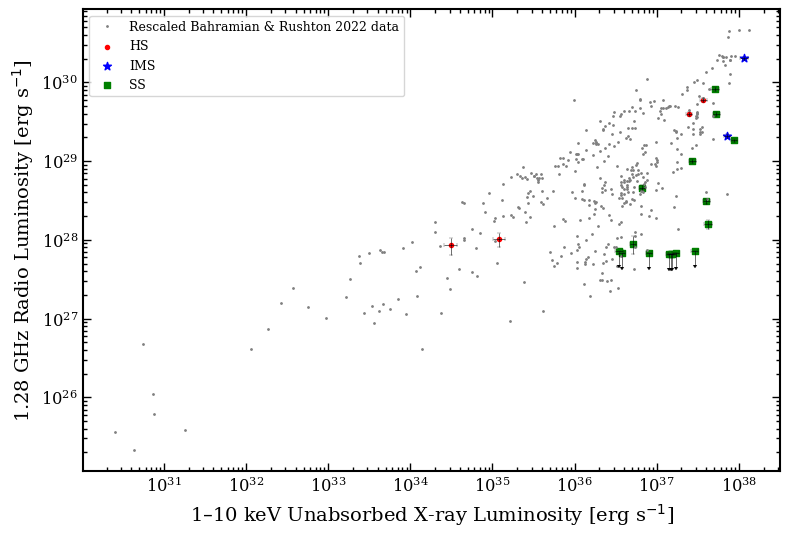

In [14]:
plot_Lr_Lx(interpolated_data, colourby="state", lx=lx_all, lr=lr_all)